Q-Training Model (Revised)
- stateless Q-learning
- stronger convergence definition
- continuous + grid benchmark comparison
- steady-state average learned weights
- convergence speed (cumulative reward gap)
- hyperparameter and random-seed experiments

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import deque
from itertools import product

In [50]:
# =========================================================
# 1. LOAD DATA
# =========================================================

outdir = Path("project3_outputs")

mu_hat = np.load(outdir / "mu_hat.npy")
Sigma_hat = np.load(outdir / "Sigma_hat.npy")

Sigma_df = pd.read_csv(outdir / "covariance_matrix.csv", index_col=0)
asset_names = list(Sigma_df.columns)

# bounded action grid exported from optimalBenchmark.ipynb
action_file = outdir / "bounded_feasible_weights.csv"
weights_df = pd.read_csv(action_file)
action_grid = weights_df[["w1", "w2", "w3"]].values.astype(float)

# optional continuous bounded benchmark
continuous_benchmark_path = outdir / "bounded_benchmark_weights.csv"
continuous_benchmark_weights = None
if continuous_benchmark_path.exists():
    cont_df = pd.read_csv(continuous_benchmark_path)
    continuous_benchmark_weights = cont_df["weight"].values.astype(float)

print("Assets:", asset_names)
print("mu_hat:", mu_hat)
print("Sigma_hat:\n", Sigma_hat)
print("Action file:", action_file)
print("Number of feasible actions:", len(action_grid))
print(weights_df.head())

if continuous_benchmark_weights is not None:
    print("Continuous benchmark weights:", continuous_benchmark_weights)

Assets: ['SPY', 'IEF', 'GLD']
mu_hat: [ 0.00051575 -0.00024641  0.00032329]
Sigma_hat:
 [[1.08500755e-04 5.42930040e-06 1.54645268e-05]
 [5.42930040e-06 2.63825810e-05 1.88849140e-05]
 [1.54645268e-05 1.88849140e-05 8.14528009e-05]]
Action file: project3_outputs/bounded_feasible_weights.csv
Number of feasible actions: 306
    w1   w2   w3
0 -0.5 -0.0  1.5
1 -0.5  0.1  1.4
2 -0.5  0.2  1.3
3 -0.5  0.3  1.2
4 -0.5  0.4  1.1
Continuous benchmark weights: [ 0.98354359 -0.5         0.51645641]


In [51]:
# =========================================================
# 2. REWARD + ENVIRONMENT
# =========================================================

def portfolio_return(weights, asset_returns):
    w = np.asarray(weights, dtype=float)
    r = np.asarray(asset_returns, dtype=float)

    if w.ndim != 1 or r.ndim != 1:
        raise ValueError("weights and asset_returns must both be 1D arrays")
    if w.shape[0] != r.shape[0]:
        raise ValueError("weights and asset_returns must have the same length")
    if not np.isfinite(w).all() or not np.isfinite(r).all():
        raise ValueError("weights and asset_returns must contain only finite values")

    return float(np.dot(w, r))


def reward_from_portfolio_return(portfolio_ret, gamma):
    if gamma < 0:
        raise ValueError("gamma must be non-negative")
    rp = float(portfolio_ret)
    return float(rp - 0.5 * gamma * (rp ** 2))


def mean_variance_reward(weights, asset_returns, gamma):
    rp = portfolio_return(weights, asset_returns)
    return reward_from_portfolio_return(rp, gamma)


def sample_one_return(mu, Sigma, rng):
    mu = np.asarray(mu, dtype=float)
    Sigma = np.asarray(Sigma, dtype=float)
    return rng.multivariate_normal(mean=mu, cov=Sigma)

In [52]:
# =========================================================
# 3. BENCHMARKS
# =========================================================

def utility_from_moments(weights, mu, Sigma, gamma):
    w = np.asarray(weights, dtype=float)
    mu = np.asarray(mu, dtype=float)
    Sigma = np.asarray(Sigma, dtype=float)

    mean_ = float(w @ mu)
    var_ = float(w @ Sigma @ w)
    utility_ = float(mean_ - 0.5 * gamma * var_)
    return {
        "mean": mean_,
        "variance": var_,
        "utility": utility_,
    }


def best_grid_benchmark(action_grid, mu, Sigma, gamma):
    utilities = []
    for w in action_grid:
        u = utility_from_moments(w, mu, Sigma, gamma)["utility"]
        utilities.append(u)

    utilities = np.array(utilities)
    idx = int(np.argmax(utilities))

    return {
        "best_idx": idx,
        "best_weights": action_grid[idx],
        "best_utility": float(utilities[idx]),
        "all_utilities": utilities,
    }


def build_benchmark_bundle(action_grid, mu, Sigma, gamma, continuous_weights=None):
    grid_bench = best_grid_benchmark(action_grid, mu, Sigma, gamma)

    bundle = {
        "grid_idx": grid_bench["best_idx"],
        "grid_weights": grid_bench["best_weights"],
        "grid_stats": utility_from_moments(grid_bench["best_weights"], mu, Sigma, gamma),
    }

    if continuous_weights is not None:
        bundle["continuous_weights"] = continuous_weights
        bundle["continuous_stats"] = utility_from_moments(continuous_weights, mu, Sigma, gamma)
    else:
        bundle["continuous_weights"] = None
        bundle["continuous_stats"] = None

    return bundle

In [53]:
# =========================================================
# 4. Q-LEARNING
# =========================================================

def epsilon_greedy_action(Q, epsilon, rng):
    if rng.random() < epsilon:
        return int(rng.integers(len(Q)))
    return int(np.argmax(Q))


def compute_recent_average_weights(weight_history, window):
    if len(weight_history) < window:
        return None
    arr = np.asarray(weight_history[-window:], dtype=float)
    return arr.mean(axis=0)


def train_q_learning(
        mu,
        Sigma,
        action_grid,
        gamma=3.0,
        alpha=0.05,
        beta=0.001,
        discount=0.95,
        max_iter=50000,
        convergence_window=2000,   # kept only for compatibility
        q_tol=1e-6,                # kept only for compatibility
        weight_tol=5e-3,
        benchmark_tol=0.15,        # kept only for compatibility
        grid_benchmark_weights=None,
        seed=42,
        verbose=False
):
    """
    Stateless Q-learning:
        Q(a_t) <- Q(a_t) + alpha * [reward + discount * max_a' Q(a') - Q(a_t)]

    Convergence definition used in the write-up:
    the model is considered converged when the Euclidean distance
    between consecutive chosen portfolio weights w_t and w_{t-1}
    is sufficiently small.

    Here, "sufficiently small" means:
        || w_t - w_{t-1} ||_2 < weight_tol
    """
    rng = np.random.default_rng(seed)

    n_actions = len(action_grid)
    Q = np.zeros(n_actions, dtype=float)

    reward_history = []
    epsilon_history = []
    action_history = []
    best_action_history = []
    q_max_history = []
    q_change_history = []
    chosen_weight_history = []

    converged = False
    convergence_iter = None
    convergence_details = {}

    prev_w = None

    for t in range(1, max_iter + 1):
        epsilon = float(np.exp(-beta * t))
        old_Q = Q.copy()

        a_idx = epsilon_greedy_action(Q, epsilon, rng)
        w = action_grid[a_idx]

        r_next = sample_one_return(mu, Sigma, rng)
        reward = mean_variance_reward(w, r_next, gamma)

        td_target = reward + discount * np.max(Q)
        td_error = td_target - Q[a_idx]
        Q[a_idx] = Q[a_idx] + alpha * td_error

        current_best_idx = int(np.argmax(Q))
        q_change = float(np.max(np.abs(Q - old_Q)))

        reward_history.append(reward)
        epsilon_history.append(epsilon)
        action_history.append(a_idx)
        best_action_history.append(current_best_idx)
        q_max_history.append(float(np.max(Q)))
        q_change_history.append(q_change)
        chosen_weight_history.append(w.copy())

        # -------------------------------------------------
        # Convergence rule from the write-up:
        # Euclidean distance between w_t and w_{t-1}
        # -------------------------------------------------
        if prev_w is not None:
            weight_distance = float(np.linalg.norm(w - prev_w))

            if weight_distance < weight_tol:
                converged = True
                convergence_iter = t
                convergence_details = {
                    "definition": "euclidean distance between consecutive weights",
                    "weight_distance": weight_distance,
                    "weight_tol": weight_tol,
                    "current_weights": w.copy(),
                    "previous_weights": prev_w.copy(),
                    # keep these keys for downstream compatibility
                    "formal_converged": converged,
                    "practical_converged": converged,
                    "best_action_stable": np.nan,
                    "q_changes_small": np.nan,
                    "weight_stable": converged,
                    "most_common_action_share": np.nan,
                    "q_small_share": np.nan,
                    "benchmark_distance": np.nan,
                    "recent_avg_weights": None,
                    "prev_avg_weights": None,
                }

                if verbose:
                    print(f"Converged at iteration {t}")
                    print(f"Current weights: {w}")
                    print(f"Previous weights: {prev_w}")
                    print(f"Euclidean distance: {weight_distance}")
                    print(f"Tolerance: {weight_tol}")
                break

        prev_w = w.copy()

    if not converged:
        convergence_iter = max_iter
        convergence_details = {
            "definition": "euclidean distance between consecutive weights",
            "weight_distance": np.nan,
            "weight_tol": weight_tol,
            "current_weights": chosen_weight_history[-1].copy() if len(chosen_weight_history) > 0 else None,
            "previous_weights": chosen_weight_history[-2].copy() if len(chosen_weight_history) > 1 else None,
            # keep these keys for downstream compatibility
            "formal_converged": False,
            "practical_converged": False,
            "best_action_stable": np.nan,
            "q_changes_small": np.nan,
            "weight_stable": False,
            "most_common_action_share": np.nan,
            "q_small_share": np.nan,
            "benchmark_distance": np.nan,
            "recent_avg_weights": None,
            "prev_avg_weights": None,
        }

        if verbose:
            print("Did not meet convergence rule before max_iter.")
            print(f"Using final iteration = {max_iter}")

    best_action_idx = int(np.argmax(Q))
    best_weights = action_grid[best_action_idx]

    return {
        "Q": Q,
        "best_action_idx": best_action_idx,
        "best_weights": best_weights,
        "reward_history": np.array(reward_history),
        "epsilon_history": np.array(epsilon_history),
        "action_history": np.array(action_history),
        "best_action_history": np.array(best_action_history),
        "q_max_history": np.array(q_max_history),
        "q_change_history": np.array(q_change_history),
        "chosen_weight_history": np.asarray(chosen_weight_history),
        "converged": converged,
        "convergence_iter": convergence_iter,
        "convergence_details": convergence_details,
        "params": {
            "gamma": gamma,
            "alpha": alpha,
            "beta": beta,
            "discount": discount,
            "max_iter": max_iter,
            "convergence_window": convergence_window,
            "q_tol": q_tol,
            "weight_tol": weight_tol,
            "seed": seed,
        },
    }

In [54]:
# =========================================================
# 5. TRAINING-PATH AVERAGE WEIGHTS + FIXED-POLICY EVALUATION
# =========================================================

def average_learned_weights_from_training(train_result, window=None):
    """
    Compute average learned weights directly from the realized training path.

    This is closer to the project requirement
        wbar_QL = (1/T) * sum_t w_t^{QL}
    than simply repeating the final best action.
    """
    weight_history = np.asarray(train_result["chosen_weight_history"], dtype=float)

    if weight_history.ndim != 2 or len(weight_history) == 0:
        raise ValueError("chosen_weight_history is empty or malformed")

    if window is not None:
        if window <= 0:
            raise ValueError("window must be positive")
        window = min(window, len(weight_history))
        weight_history = weight_history[-window:]

    return weight_history.mean(axis=0)


def fixed_policy_evaluation(
        learned_weights,
        mu,
        Sigma,
        gamma,
        T=5000,
        seed=999
):
    """
    Evaluate a fixed portfolio policy after training.

    This is a supplementary diagnostic.
    The main 'average learned weights' comparison should come
    from average_learned_weights_from_training(...).
    """
    rng = np.random.default_rng(seed)

    weights_path = []
    rewards = []
    returns = []

    learned_weights = np.asarray(learned_weights, dtype=float)

    for _ in range(T):
        r_next = sample_one_return(mu, Sigma, rng)
        rp = portfolio_return(learned_weights, r_next)
        rw = reward_from_portfolio_return(rp, gamma)

        weights_path.append(learned_weights.copy())
        returns.append(rp)
        rewards.append(rw)

    weights_path = np.asarray(weights_path)
    returns = np.asarray(returns)
    rewards = np.asarray(rewards)

    return {
        "avg_fixed_policy_weights": weights_path.mean(axis=0),
        "mean_portfolio_return": float(returns.mean()),
        "var_portfolio_return": float(returns.var(ddof=1)),
        "mean_reward": float(rewards.mean()),
        "weights_path": weights_path,
        "returns": returns,
        "rewards": rewards,
    }

In [55]:
# =========================================================
# 6. CONVERGENCE SPEED / SAME-PATH COMPARISON
# =========================================================

def compare_policies_on_same_path(
        learned_weights,
        grid_benchmark_weights,
        mu,
        Sigma,
        gamma,
        T=5000,
        seed=2025,
        continuous_benchmark_weights=None
):
    """
    Compare learned policy and benchmark policies on the same simulated path.
    """
    rng = np.random.default_rng(seed)

    learned_rewards = []
    grid_rewards = []
    cont_rewards = [] if continuous_benchmark_weights is not None else None

    learned_weights = np.asarray(learned_weights, dtype=float)
    grid_benchmark_weights = np.asarray(grid_benchmark_weights, dtype=float)
    if continuous_benchmark_weights is not None:
        continuous_benchmark_weights = np.asarray(continuous_benchmark_weights, dtype=float)

    for _ in range(T):
        r_next = sample_one_return(mu, Sigma, rng)

        rp_learned = portfolio_return(learned_weights, r_next)
        rp_grid = portfolio_return(grid_benchmark_weights, r_next)

        learned_rewards.append(reward_from_portfolio_return(rp_learned, gamma))
        grid_rewards.append(reward_from_portfolio_return(rp_grid, gamma))

        if continuous_benchmark_weights is not None:
            rp_cont = portfolio_return(continuous_benchmark_weights, r_next)
            cont_rewards.append(reward_from_portfolio_return(rp_cont, gamma))

    learned_rewards = np.asarray(learned_rewards)
    grid_rewards = np.asarray(grid_rewards)

    out = {
        "learned_rewards": learned_rewards,
        "grid_rewards": grid_rewards,
        "grid_reward_gap": grid_rewards - learned_rewards,
        "cum_grid_reward_gap": np.cumsum(grid_rewards - learned_rewards),
        "mean_grid_reward_gap": float(np.mean(grid_rewards - learned_rewards)),
    }

    if continuous_benchmark_weights is not None:
        cont_rewards = np.asarray(cont_rewards)
        out["continuous_rewards"] = cont_rewards
        out["continuous_reward_gap"] = cont_rewards - learned_rewards
        out["cum_continuous_reward_gap"] = np.cumsum(cont_rewards - learned_rewards)
        out["mean_continuous_reward_gap"] = float(np.mean(cont_rewards - learned_rewards))

    return out

In [56]:
# =========================================================
# 7. HYPERPARAMETER + SEED EXPERIMENTS
# =========================================================

def run_hyperparameter_seed_experiments(
        mu,
        Sigma,
        action_grid,
        gamma,
        alpha_list,
        beta_list,
        discount_list,
        seed_list,
        max_iter=500000,
        convergence_window=2000,
        q_tol=1e-10,
        weight_tol=1e-4,
        continuous_weights=None,
):
    benchmarks = build_benchmark_bundle(
        action_grid=action_grid,
        mu=mu,
        Sigma=Sigma,
        gamma=gamma,
        continuous_weights=continuous_weights,
    )

    rows = []
    detailed_runs = []

    total_runs = len(alpha_list) * len(beta_list) * len(discount_list) * len(seed_list)
    run_counter = 0

    for alpha, beta, discount, seed in product(alpha_list, beta_list, discount_list, seed_list):
        run_counter += 1
        print(f"Running {run_counter}/{total_runs} | alpha={alpha}, beta={beta}, discount={discount}, seed={seed}")

        result = train_q_learning(
            mu=mu,
            Sigma=Sigma,
            action_grid=action_grid,
            gamma=gamma,
            alpha=alpha,
            beta=beta,
            discount=discount,
            max_iter=max_iter,
            convergence_window=convergence_window,
            q_tol=q_tol,
            weight_tol=weight_tol,
            benchmark_tol=0.15,
            grid_benchmark_weights=benchmarks["grid_weights"],
            seed=seed,
            verbose=False,
        )

        learned_weights = result["best_weights"]
        avg_training_weights = average_learned_weights_from_training(
            result,
            window=min(convergence_window, len(result["chosen_weight_history"]))
        )

        learned_stats = utility_from_moments(learned_weights, mu, Sigma, gamma)
        avg_training_stats = utility_from_moments(avg_training_weights, mu, Sigma, gamma)

        distance_to_grid = float(np.linalg.norm(learned_weights - benchmarks["grid_weights"]))
        distance_avg_training_to_grid = float(np.linalg.norm(avg_training_weights - benchmarks["grid_weights"]))

        utility_gap_to_grid = float(benchmarks["grid_stats"]["utility"] - learned_stats["utility"])
        utility_gap_avg_training_to_grid = float(
            benchmarks["grid_stats"]["utility"] - avg_training_stats["utility"]
        )

        if benchmarks["continuous_weights"] is not None:
            distance_to_cont = float(np.linalg.norm(learned_weights - benchmarks["continuous_weights"]))
            distance_avg_training_to_cont = float(
                np.linalg.norm(avg_training_weights - benchmarks["continuous_weights"])
            )

            utility_gap_to_cont = float(benchmarks["continuous_stats"]["utility"] - learned_stats["utility"])
            utility_gap_avg_training_to_cont = float(
                benchmarks["continuous_stats"]["utility"] - avg_training_stats["utility"]
            )
        else:
            distance_to_cont = np.nan
            distance_avg_training_to_cont = np.nan
            utility_gap_to_cont = np.nan
            utility_gap_avg_training_to_cont = np.nan

        row = {
            "alpha": alpha,
            "beta": beta,
            "discount": discount,
            "seed": seed,
            "converged": result["converged"],
            "convergence_iter": result["convergence_iter"],
            "best_action_idx": result["best_action_idx"],
            "w1": learned_weights[0],
            "w2": learned_weights[1],
            "w3": learned_weights[2],
            "avg_train_w1": avg_training_weights[0],
            "avg_train_w2": avg_training_weights[1],
            "avg_train_w3": avg_training_weights[2],
            "distance_to_grid_benchmark": distance_to_grid,
            "distance_to_continuous_benchmark": distance_to_cont,
            "distance_avg_training_to_grid": distance_avg_training_to_grid,
            "distance_avg_training_to_continuous": distance_avg_training_to_cont,
            "learned_mean": learned_stats["mean"],
            "learned_variance": learned_stats["variance"],
            "learned_utility": learned_stats["utility"],
            "grid_benchmark_utility": benchmarks["grid_stats"]["utility"],
            "utility_gap_to_grid": utility_gap_to_grid,
            "utility_gap_to_continuous": utility_gap_to_cont,
            "utility_gap_avg_training_to_grid": utility_gap_avg_training_to_grid,
            "utility_gap_avg_training_to_continuous": utility_gap_avg_training_to_cont,
            "grid_w1": benchmarks["grid_weights"][0],
            "grid_w2": benchmarks["grid_weights"][1],
            "grid_w3": benchmarks["grid_weights"][2],
        }

        rows.append(row)

        detailed_runs.append({
            "config": {
                "alpha": alpha,
                "beta": beta,
                "discount": discount,
                "seed": seed,
            },
            "result": result,
        })

    results_df = pd.DataFrame(rows)
    return results_df, detailed_runs, benchmarks

In [57]:
# =========================================================
# 8. CONFIG
# =========================================================

gamma = 3.0

# slightly broader grid
alpha_list = [0.005, 0.01, 0.02, 0.05]
beta_list = [0.0005, 0.001, 0.002]
discount_list = [0.0, 0.5, 0.9, 0.95, 0.99]
seed_list = [42, 123, 2024]

seed_list = [42, 123, 2024]

max_iter = 500000
convergence_window = 2000
q_tol = 1e-6
weight_tol = 5e-3
steady_state_T = 5000
same_path_T = 5000

In [58]:
# =========================================================
# 9. RUN EXPERIMENTS
# =========================================================

results_df, detailed_runs, benchmarks = run_hyperparameter_seed_experiments(
    mu=mu_hat,
    Sigma=Sigma_hat,
    action_grid=action_grid,
    gamma=gamma,
    alpha_list=alpha_list,
    beta_list=beta_list,
    discount_list=discount_list,
    seed_list=seed_list,
    max_iter=max_iter,
    convergence_window=convergence_window,
    q_tol=q_tol,
    weight_tol=weight_tol,
    continuous_weights=continuous_benchmark_weights,
)

print("\n===== Benchmarks =====")
print("Grid benchmark weights:", benchmarks["grid_weights"])
print("Grid benchmark utility:", benchmarks["grid_stats"]["utility"])
if benchmarks["continuous_weights"] is not None:
    print("Continuous benchmark weights:", benchmarks["continuous_weights"])
    print("Continuous benchmark utility:", benchmarks["continuous_stats"]["utility"])

Running 1/180 | alpha=0.005, beta=0.0005, discount=0.0, seed=42
Running 2/180 | alpha=0.005, beta=0.0005, discount=0.0, seed=123
Running 3/180 | alpha=0.005, beta=0.0005, discount=0.0, seed=2024
Running 4/180 | alpha=0.005, beta=0.0005, discount=0.5, seed=42
Running 5/180 | alpha=0.005, beta=0.0005, discount=0.5, seed=123
Running 6/180 | alpha=0.005, beta=0.0005, discount=0.5, seed=2024
Running 7/180 | alpha=0.005, beta=0.0005, discount=0.9, seed=42
Running 8/180 | alpha=0.005, beta=0.0005, discount=0.9, seed=123
Running 9/180 | alpha=0.005, beta=0.0005, discount=0.9, seed=2024
Running 10/180 | alpha=0.005, beta=0.0005, discount=0.95, seed=42
Running 11/180 | alpha=0.005, beta=0.0005, discount=0.95, seed=123
Running 12/180 | alpha=0.005, beta=0.0005, discount=0.95, seed=2024
Running 13/180 | alpha=0.005, beta=0.0005, discount=0.99, seed=42
Running 14/180 | alpha=0.005, beta=0.0005, discount=0.99, seed=123
Running 15/180 | alpha=0.005, beta=0.0005, discount=0.99, seed=2024
Running 16/18

In [59]:
# =========================================================
# 10. SAVE RESULTS
# =========================================================

results_path = outdir / "q_learning_hyperparameter_seed_results.csv"
results_df.to_csv(results_path, index=False)

print("Saved results to:", results_path)
print(results_df.head())

Saved results to: project3_outputs/q_learning_hyperparameter_seed_results.csv
   alpha    beta  discount  seed  converged  convergence_iter  \
0  0.005  0.0005       0.0    42       True                93   
1  0.005  0.0005       0.0   123       True               175   
2  0.005  0.0005       0.0  2024       True                14   
3  0.005  0.0005       0.5    42       True                93   
4  0.005  0.0005       0.5   123       True               175   

   best_action_idx   w1   w2   w3  ...  learned_variance  learned_utility  \
0                1 -0.5  0.1  1.4  ...          0.000170        -0.000085   
1               53 -0.2 -0.1  1.3  ...          0.000130         0.000147   
2               28 -0.4  1.1  0.3  ...          0.000061        -0.000471   
3                1 -0.5  0.1  1.4  ...          0.000170        -0.000085   
4               53 -0.2 -0.1  1.3  ...          0.000130         0.000147   

   grid_benchmark_utility  utility_gap_to_grid  utility_gap_to_conti

In [60]:
# =========================================================
# 11. BEST RUNS
# =========================================================

best_by_distance = results_df.sort_values(
    by=[
        "converged",
        "distance_avg_training_to_grid",
        "utility_gap_avg_training_to_grid",
        "convergence_iter"
    ],
    ascending=[False, True, True, True]
).reset_index(drop=True)

print("===== Top 10 runs by distance to grid benchmark =====")
print(best_by_distance.head(10))

===== Top 10 runs by distance to grid benchmark =====
   alpha   beta  discount  seed  converged  convergence_iter  best_action_idx  \
0  0.005  0.001      0.00    42       True                85              289   
1  0.005  0.001      0.50    42       True                85              289   
2  0.005  0.001      0.90    42       True                85              289   
3  0.005  0.001      0.95    42       True                85              289   
4  0.005  0.001      0.99    42       True                85              289   
5  0.010  0.001      0.00    42       True                85              289   
6  0.010  0.001      0.50    42       True                85              289   
7  0.010  0.001      0.90    42       True                85              289   
8  0.010  0.001      0.95    42       True                85              289   
9  0.010  0.001      0.99    42       True                85              289   

    w1   w2   w3  ...  learned_variance  learned_utili

In [61]:
# =========================================================
# 12. SUMMARY BY HYPERPARAMS
# =========================================================

summary_by_hyperparams = (
    results_df.groupby(["alpha", "beta", "discount"])
    .agg(
        n_runs=("seed", "count"),
        n_converged=("converged", "sum"),
        avg_convergence_iter=("convergence_iter", "mean"),
        avg_distance_to_grid=("distance_to_grid_benchmark", "mean"),
        avg_distance_avg_training_to_grid=("distance_avg_training_to_grid", "mean"),
        min_distance_avg_training_to_grid=("distance_avg_training_to_grid", "min"),
        avg_distance_to_continuous=("distance_to_continuous_benchmark", "mean"),
        avg_distance_avg_training_to_continuous=("distance_avg_training_to_continuous", "mean"),
        avg_utility_gap_grid=("utility_gap_to_grid", "mean"),
        avg_utility_gap_avg_training_grid=("utility_gap_avg_training_to_grid", "mean"),
        min_utility_gap_avg_training_grid=("utility_gap_avg_training_to_grid", "min"),
    )
    .reset_index()
    .sort_values(
        by=["n_converged", "avg_distance_avg_training_to_grid", "avg_utility_gap_avg_training_grid"],
        ascending=[False, True, True]
    )
)

print("===== Summary by hyperparameter setting =====")
print(summary_by_hyperparams)

===== Summary by hyperparameter setting =====
    alpha    beta  discount  n_runs  n_converged  avg_convergence_iter  \
5   0.005  0.0010      0.00       3            3            106.666667   
6   0.005  0.0010      0.50       3            3            106.666667   
20  0.010  0.0010      0.00       3            3            106.666667   
21  0.010  0.0010      0.50       3            3            106.666667   
22  0.010  0.0010      0.90       3            3            106.666667   
35  0.020  0.0010      0.00       3            3            106.666667   
36  0.020  0.0010      0.50       3            3            106.666667   
37  0.020  0.0010      0.90       3            3            106.666667   
38  0.020  0.0010      0.95       3            3            106.666667   
39  0.020  0.0010      0.99       3            3            106.666667   
50  0.050  0.0010      0.00       3            3            106.666667   
51  0.050  0.0010      0.50       3            3            106.66

In [62]:
# =========================================================
# 13. BEST SINGLE RUN
# =========================================================

best_row = best_by_distance.iloc[0]
print("===== Best Single Run =====")
for col in best_row.index:
    print(f"{col}: {best_row[col]}")

===== Best Single Run =====
alpha: 0.005
beta: 0.001
discount: 0.0
seed: 42
converged: True
convergence_iter: 85
best_action_idx: 289
w1: 1.3
w2: -0.1
w3: -0.2
avg_train_w1: 0.4376470588235293
avg_train_w2: 0.21058823529411758
avg_train_w3: 0.35176470588235315
distance_to_grid_benchmark: 0.8602325267042626
distance_to_continuous_benchmark: 0.8794625928797114
distance_avg_training_to_grid: 0.9182320910371083
distance_avg_training_to_continuous: 0.9110773942403635
learned_mean: 0.0006304550312456699
learned_variance: 0.00017819043894134443
learned_utility: 0.00036316937283365327
grid_benchmark_utility: 0.000596518511394103
utility_gap_to_grid: 0.00023334913856044978
utility_gap_to_continuous: 0.0002334137375365759
utility_gap_avg_training_to_grid: 0.0003698587454352276
utility_gap_avg_training_to_continuous: 0.0003699233444113537
grid_w1: 1.0
grid_w2: -0.5
grid_w3: 0.5


In [63]:
# =========================================================
# 14. GET BEST RUN DETAIL
# =========================================================

best_alpha = best_row["alpha"]
best_beta = best_row["beta"]
best_discount = best_row["discount"]
best_seed = best_row["seed"]

best_run_detail = None
for item in detailed_runs:
    cfg = item["config"]
    if (
            cfg["alpha"] == best_alpha
            and cfg["beta"] == best_beta
            and cfg["discount"] == best_discount
            and cfg["seed"] == best_seed
    ):
        best_run_detail = item
        break

if best_run_detail is None:
    raise RuntimeError("Could not locate the detailed best run.")

best_result = best_run_detail["result"]
print("Best run learned weights:", best_result["best_weights"])
print("Best run convergence details:", best_result["convergence_details"])
print("Best run convergence iteration:", best_result["convergence_iter"])
print("Best run converged:", best_result["converged"])
print("Convergence details:", best_result["convergence_details"])

Best run learned weights: [ 1.3 -0.1 -0.2]
Best run convergence details: {'definition': 'euclidean distance between consecutive weights', 'weight_distance': 0.0, 'weight_tol': 0.005, 'current_weights': array([ 1.3, -0.1, -0.2]), 'previous_weights': array([ 1.3, -0.1, -0.2]), 'formal_converged': True, 'practical_converged': True, 'best_action_stable': nan, 'q_changes_small': nan, 'weight_stable': True, 'most_common_action_share': nan, 'q_small_share': nan, 'benchmark_distance': nan, 'recent_avg_weights': None, 'prev_avg_weights': None}
Best run convergence iteration: 85
Best run converged: True
Convergence details: {'definition': 'euclidean distance between consecutive weights', 'weight_distance': 0.0, 'weight_tol': 0.005, 'current_weights': array([ 1.3, -0.1, -0.2]), 'previous_weights': array([ 1.3, -0.1, -0.2]), 'formal_converged': True, 'practical_converged': True, 'best_action_stable': nan, 'q_changes_small': nan, 'weight_stable': True, 'most_common_action_share': nan, 'q_small_shar

In [64]:
# =========================================================
# 15. AVERAGE LEARNED WEIGHTS + FIXED-POLICY DIAGNOSTIC
# =========================================================

avg_learned_weights = average_learned_weights_from_training(
    best_result,
    window=min(convergence_window, len(best_result["chosen_weight_history"]))
)

fixed_policy_eval = fixed_policy_evaluation(
    learned_weights=best_result["best_weights"],
    mu=mu_hat,
    Sigma=Sigma_hat,
    gamma=gamma,
    T=steady_state_T,
    seed=999,
)

print("===== Average Learned Weights from Training Path =====")
print("Average learned weights (training path):", avg_learned_weights)

avg_training_stats = utility_from_moments(avg_learned_weights, mu_hat, Sigma_hat, gamma)
print("Avg-training-path mean:", avg_training_stats["mean"])
print("Avg-training-path variance:", avg_training_stats["variance"])
print("Avg-training-path utility:", avg_training_stats["utility"])

dist_avg_to_grid = np.linalg.norm(avg_learned_weights - benchmarks["grid_weights"])
print("Distance(avg learned training path, grid benchmark):", dist_avg_to_grid)

if benchmarks["continuous_weights"] is not None:
    dist_avg_to_cont = np.linalg.norm(avg_learned_weights - benchmarks["continuous_weights"])
    print("Distance(avg learned training path, continuous benchmark):", dist_avg_to_cont)

print("\n===== Fixed-Policy Diagnostic =====")
print("Fixed policy weights:", best_result["best_weights"])
print("Fixed-policy mean portfolio return:", fixed_policy_eval["mean_portfolio_return"])
print("Fixed-policy variance of portfolio return:", fixed_policy_eval["var_portfolio_return"])
print("Fixed-policy mean reward:", fixed_policy_eval["mean_reward"])

===== Average Learned Weights from Training Path =====
Average learned weights (training path): [0.43764706 0.21058824 0.35176471]
Avg-training-path mean: 0.0002875457789470066
Avg-training-path variance: 4.0590675325420743e-05
Avg-training-path utility: 0.0002266597659588755
Distance(avg learned training path, grid benchmark): 0.9182320910371083
Distance(avg learned training path, continuous benchmark): 0.9110773942403635

===== Fixed-Policy Diagnostic =====
Fixed policy weights: [ 1.3 -0.1 -0.2]
Fixed-policy mean portfolio return: 0.0005714198421171695
Fixed-policy variance of portfolio return: 0.00017344693467463248
Fixed-policy mean reward: 0.0003108116932316753


# Extra Credit

In [65]:
# =========================================================
# 16. CONVERGENCE SPEED / SAME-PATH COMPARISON
# =========================================================

speed_eval = compare_policies_on_same_path(
    learned_weights=avg_learned_weights,
    grid_benchmark_weights=benchmarks["grid_weights"],
    continuous_benchmark_weights=benchmarks["continuous_weights"],
    mu=mu_hat,
    Sigma=Sigma_hat,
    gamma=gamma,
    T=same_path_T,
    seed=2025,
)

print("===== Convergence Speed / Reward Gap =====")
print("Mean reward gap vs grid benchmark:", speed_eval["mean_grid_reward_gap"])
print("Final cumulative reward gap vs grid benchmark:", speed_eval["cum_grid_reward_gap"][-1])

if "mean_continuous_reward_gap" in speed_eval:
    print("Mean reward gap vs continuous benchmark:", speed_eval["mean_continuous_reward_gap"])
    print("Final cumulative reward gap vs continuous benchmark:", speed_eval["cum_continuous_reward_gap"][-1])

===== Convergence Speed / Reward Gap =====
Mean reward gap vs grid benchmark: 0.0003441845643886855
Final cumulative reward gap vs grid benchmark: 1.7209228219434272
Mean reward gap vs continuous benchmark: 0.00034327884539813743
Final cumulative reward gap vs continuous benchmark: 1.7163942269906876


In [66]:
# =========================================================
# 17. PLOTTING FUNCTIONS
# =========================================================

def plot_training_results(train_result, rolling_window=200):
    reward_history = train_result["reward_history"]
    epsilon_history = train_result["epsilon_history"]
    best_action_history = train_result["best_action_history"]
    q_max_history = train_result["q_max_history"]

    if len(reward_history) >= rolling_window:
        rolling_reward = np.convolve(
            reward_history,
            np.ones(rolling_window) / rolling_window,
            mode="valid"
        )
    else:
        rolling_reward = reward_history

    plt.figure(figsize=(8, 4))
    plt.plot(rolling_reward)
    plt.title("Rolling Average Reward")
    plt.xlabel("Iteration")
    plt.ylabel("Reward")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(epsilon_history)
    plt.title("Epsilon Decay")
    plt.xlabel("Iteration")
    plt.ylabel("Epsilon")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(best_action_history)
    plt.title("Best Action Index Over Time")
    plt.xlabel("Iteration")
    plt.ylabel("Best Action Index")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(q_max_history)
    plt.title("Max Q-value Over Time")
    plt.xlabel("Iteration")
    plt.ylabel("Max Q")
    plt.tight_layout()
    plt.show()


def plot_weight_comparison(avg_learned_weights, grid_weights, asset_names, continuous_weights=None):
    x = np.arange(len(avg_learned_weights))
    width = 0.25

    plt.figure(figsize=(8, 4))

    if continuous_weights is not None:
        plt.bar(x - width, continuous_weights, width=width, label="Continuous Benchmark")
        plt.bar(x, grid_weights, width=width, label="Grid Benchmark")
        plt.bar(x + width, avg_learned_weights, width=width, label="Avg Learned Weights")
    else:
        plt.bar(x - width / 2, grid_weights, width=width, label="Grid Benchmark")
        plt.bar(x + width / 2, avg_learned_weights, width=width, label="Avg Learned Weights")

    plt.xticks(x, asset_names)
    plt.ylabel("Weight")
    plt.title("Average Learned Weights vs Benchmarks")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_cumulative_reward_gaps(speed_eval):
    plt.figure(figsize=(8, 4))
    plt.plot(speed_eval["cum_grid_reward_gap"], label="Grid Benchmark - Learned")
    if "cum_continuous_reward_gap" in speed_eval:
        plt.plot(speed_eval["cum_continuous_reward_gap"], label="Continuous Benchmark - Learned")
    plt.title("Cumulative Reward Gap")
    plt.xlabel("Period")
    plt.ylabel("Cumulative Reward Difference")
    plt.legend()
    plt.tight_layout()
    plt.show()

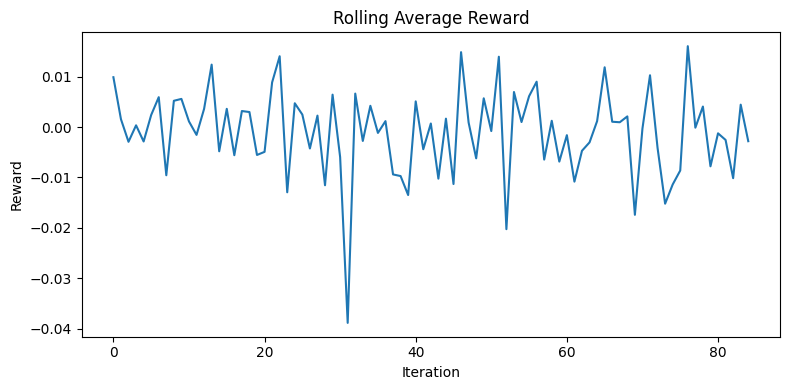

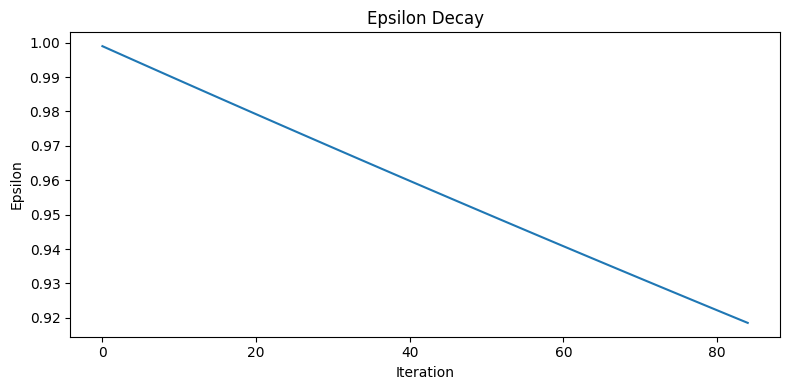

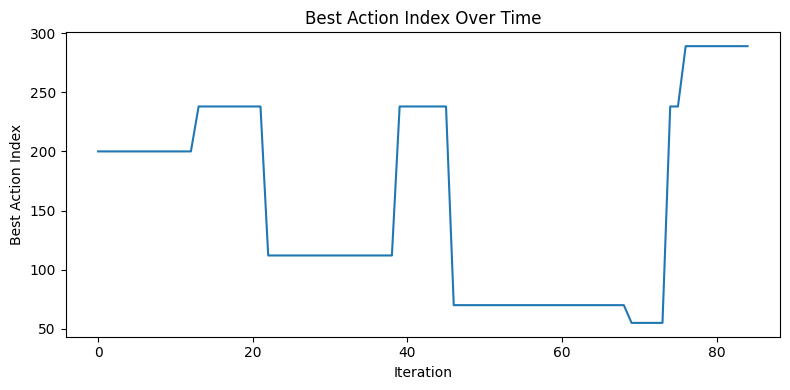

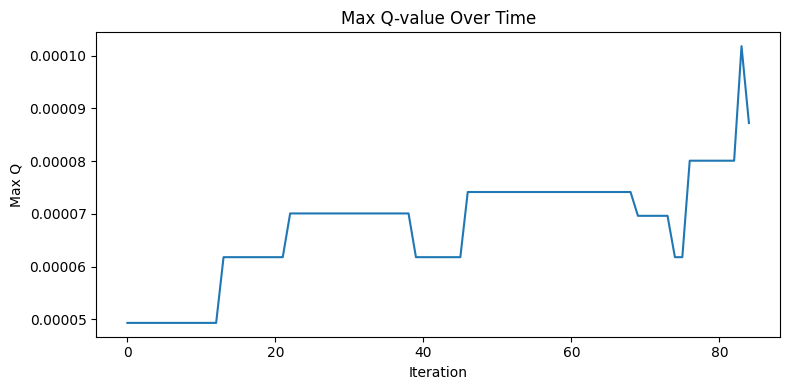

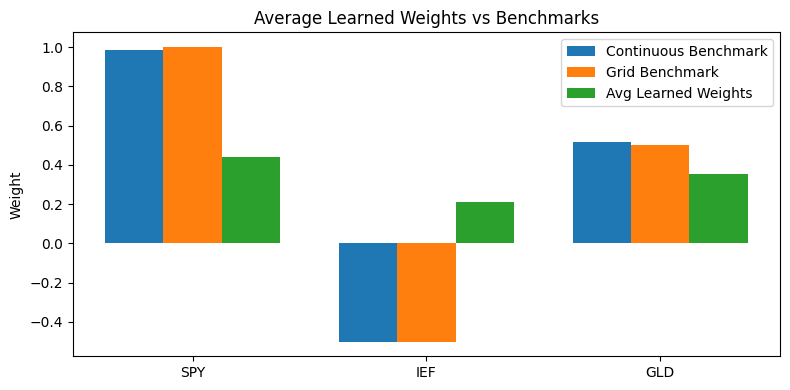

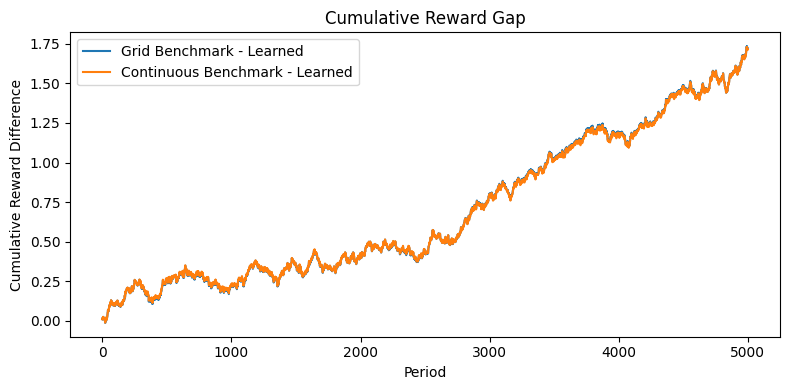

In [67]:
# =========================================================
# 18. PLOTS
# =========================================================

plot_training_results(best_result, rolling_window=200)

plot_weight_comparison(
    avg_learned_weights=avg_learned_weights,
    grid_weights=benchmarks["grid_weights"],
    continuous_weights=benchmarks["continuous_weights"],
    asset_names=asset_names,
)

plot_cumulative_reward_gaps(speed_eval)

In [68]:
# =========================================================
# 19. SEED STABILITY FOR ONE HYPERPARAM SET
# =========================================================

inspect_alpha = 0.05
inspect_beta = 0.001
inspect_discount = 0.95

subset = results_df[
    (results_df["alpha"] == inspect_alpha) &
    (results_df["beta"] == inspect_beta) &
    (results_df["discount"] == inspect_discount)
    ].copy()

subset = subset.sort_values("seed").reset_index(drop=True)

print("===== Stability across seeds =====")
print(subset[[
    "alpha", "beta", "discount", "seed",
    "converged", "convergence_iter",
    "w1", "w2", "w3",
    "avg_train_w1", "avg_train_w2", "avg_train_w3",
    "distance_to_grid_benchmark",
    "distance_avg_training_to_grid",
    "distance_to_continuous_benchmark",
    "distance_avg_training_to_continuous",
    "utility_gap_to_grid",
    "utility_gap_avg_training_to_grid",
]])

===== Stability across seeds =====
   alpha   beta  discount  seed  converged  convergence_iter   w1   w2   w3  \
0   0.05  0.001      0.95    42       True                85  1.3 -0.1 -0.2   
1   0.05  0.001      0.95   123       True               221 -0.2 -0.1  1.3   
2   0.05  0.001      0.95  2024       True                14 -0.4  1.1  0.3   

   avg_train_w1  avg_train_w2  avg_train_w3  distance_to_grid_benchmark  \
0      0.437647      0.210588      0.351765                    0.860233   
1      0.302262      0.346606      0.351131                    1.496663   
2      0.107143      0.635714      0.257143                    2.135416   

   distance_avg_training_to_grid  distance_to_continuous_benchmark  \
0                       0.918232                          0.879463   
1                       1.107132                          1.474692   
2                       1.464930                          2.126275   

   distance_avg_training_to_continuous  utility_gap_to_grid  \
0  

In [69]:
# =========================================================
# 20. SAVE A CLEAN PRESENTATION TABLE
# =========================================================

presentation_table = pd.DataFrame({
    "metric": [
        "avg learned(training path) w1", "avg learned(training path) w2", "avg learned(training path) w3",
        "fixed policy w1", "fixed policy w2", "fixed policy w3",
        "grid benchmark w1", "grid benchmark w2", "grid benchmark w3",
        "distance avg learned(training path) to grid",
        "mean reward gap vs grid",
        "final cumulative reward gap vs grid"
    ],
    "value": [
        avg_learned_weights[0], avg_learned_weights[1], avg_learned_weights[2],
        best_result["best_weights"][0], best_result["best_weights"][1], best_result["best_weights"][2],
        benchmarks["grid_weights"][0], benchmarks["grid_weights"][1], benchmarks["grid_weights"][2],
        dist_avg_to_grid,
        speed_eval["mean_grid_reward_gap"],
        speed_eval["cum_grid_reward_gap"][-1],
    ]
})

if benchmarks["continuous_weights"] is not None:
    extra = pd.DataFrame({
        "metric": [
            "continuous benchmark w1", "continuous benchmark w2", "continuous benchmark w3",
            "distance avg learned(training path) to continuous",
            "mean reward gap vs continuous",
            "final cumulative reward gap vs continuous"
        ],
        "value": [
            benchmarks["continuous_weights"][0],
            benchmarks["continuous_weights"][1],
            benchmarks["continuous_weights"][2],
            dist_avg_to_cont,
            speed_eval["mean_continuous_reward_gap"],
            speed_eval["cum_continuous_reward_gap"][-1],
        ]
    })
    presentation_table = pd.concat([presentation_table, extra], ignore_index=True)

presentation_path = outdir / "presentation_summary_table.csv"
presentation_table.to_csv(presentation_path, index=False)

print("Saved presentation summary to:", presentation_path)
print(presentation_table)

Saved presentation summary to: project3_outputs/presentation_summary_table.csv
                                               metric     value
0                       avg learned(training path) w1  0.437647
1                       avg learned(training path) w2  0.210588
2                       avg learned(training path) w3  0.351765
3                                     fixed policy w1  1.300000
4                                     fixed policy w2 -0.100000
5                                     fixed policy w3 -0.200000
6                                   grid benchmark w1  1.000000
7                                   grid benchmark w2 -0.500000
8                                   grid benchmark w3  0.500000
9         distance avg learned(training path) to grid  0.918232
10                            mean reward gap vs grid  0.000344
11                final cumulative reward gap vs grid  1.720923
12                            continuous benchmark w1  0.983544
13                       

In [70]:
# =========================================================
# REFINED FINAL EXPERIMENTS
# =========================================================

refined_configs = [
    {"alpha": 0.01, "beta": 0.001, "discount": 0.90},
    {"alpha": 0.01, "beta": 0.001, "discount": 0.95},
    {"alpha": 0.05, "beta": 0.001, "discount": 0.99},
]

refined_seed_list = [42, 123, 2024]

benchmarks_refined = build_benchmark_bundle(
    action_grid=action_grid,
    mu=mu_hat,
    Sigma=Sigma_hat,
    gamma=gamma,
    continuous_weights=continuous_benchmark_weights,
)

refined_rows = []

for cfg in refined_configs:
    for seed in refined_seed_list:
        print(f"Running refined config: {cfg}, seed={seed}")

        result = train_q_learning(
            mu=mu_hat,
            Sigma=Sigma_hat,
            action_grid=action_grid,
            gamma=gamma,
            alpha=cfg["alpha"],
            beta=cfg["beta"],
            discount=cfg["discount"],
            max_iter=500000,
            convergence_window=2000,
            q_tol=1e-6,
            weight_tol=5e-3,
            benchmark_tol=0.15,
            grid_benchmark_weights=benchmarks_refined["grid_weights"],
            seed=seed,
            verbose=False,
        )

        avg_training_weights = average_learned_weights_from_training(
            result,
            window=min(convergence_window, len(result["chosen_weight_history"]))
        )

        dist_grid = np.linalg.norm(avg_training_weights - benchmarks_refined["grid_weights"])
        util_avg = utility_from_moments(avg_training_weights, mu_hat, Sigma_hat, gamma)
        util_gap = benchmarks_refined["grid_stats"]["utility"] - util_avg["utility"]

        refined_rows.append({
            "alpha": cfg["alpha"],
            "beta": cfg["beta"],
            "discount": cfg["discount"],
            "seed": seed,
            "converged": result["converged"],
            "formal_converged": result["convergence_details"].get("formal_converged", False),
            "practical_converged": result["convergence_details"].get("practical_converged", False),
            "convergence_iter": result["convergence_iter"],
            "avg_train_w1": avg_training_weights[0],
            "avg_train_w2": avg_training_weights[1],
            "avg_train_w3": avg_training_weights[2],
            "distance_avg_training_to_grid": dist_grid,
            "utility_gap_avg_training_to_grid": util_gap,
        })

refined_results_df = pd.DataFrame(refined_rows)
print(refined_results_df.sort_values(
    by=["practical_converged", "distance_avg_training_to_grid", "utility_gap_avg_training_to_grid"],
    ascending=[False, True, True]
))

Running refined config: {'alpha': 0.01, 'beta': 0.001, 'discount': 0.9}, seed=42
Running refined config: {'alpha': 0.01, 'beta': 0.001, 'discount': 0.9}, seed=123
Running refined config: {'alpha': 0.01, 'beta': 0.001, 'discount': 0.9}, seed=2024
Running refined config: {'alpha': 0.01, 'beta': 0.001, 'discount': 0.95}, seed=42
Running refined config: {'alpha': 0.01, 'beta': 0.001, 'discount': 0.95}, seed=123
Running refined config: {'alpha': 0.01, 'beta': 0.001, 'discount': 0.95}, seed=2024
Running refined config: {'alpha': 0.05, 'beta': 0.001, 'discount': 0.99}, seed=42
Running refined config: {'alpha': 0.05, 'beta': 0.001, 'discount': 0.99}, seed=123
Running refined config: {'alpha': 0.05, 'beta': 0.001, 'discount': 0.99}, seed=2024
   alpha   beta  discount  seed  converged  formal_converged  \
0   0.01  0.001      0.90    42       True              True   
3   0.01  0.001      0.95    42       True              True   
6   0.05  0.001      0.99    42       True              True   
